# GC Example 18: Central Escape Velocity

**EPS Research — Milky Way GC Corpus v1.3.2**

The central escape velocity v_esc determines whether stars and stellar remnants
(neutron stars, black holes) can be retained after formation.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Clusters with v_esc: 154
v_esc range: 0.9 -- 128.6 km/s

Highest v_esc (black hole retention likely):
  Liller 1     v_esc=128.6 km/s  mass=1490000 Msun
  Terzan 5     v_esc=111.4 km/s  mass=2000000 Msun
  NGC 6388     v_esc=68.9 km/s  mass=1160000 Msun
  NGC 6441     v_esc=67.7 km/s  mass=1210000 Msun
  NGC 6440     v_esc=66.3 km/s  mass=612000 Msun

Lowest v_esc (neutron star kick likely to unbind):
  AM 4         v_esc=0.9 km/s
  Whiting 1    v_esc=1.1 km/s
  Pal 13       v_esc=1.6 km/s
  Pal 1        v_esc=1.9 km/s
  Crater       v_esc=2.0 km/s


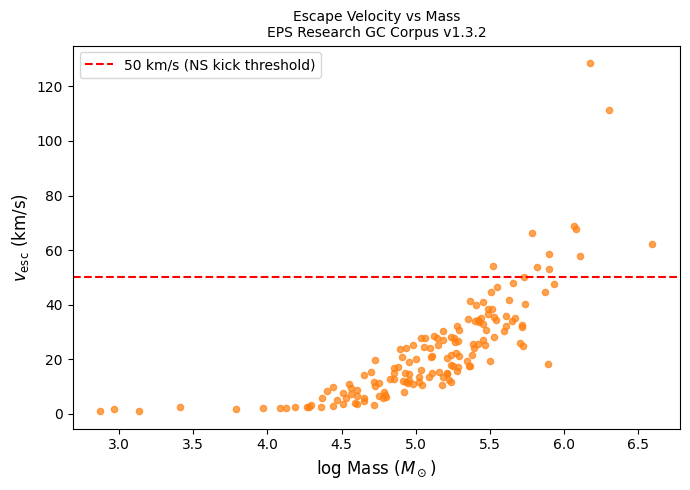

In [3]:
data=[(c['cluster_id'],c['baumgardt2023']['v_esc_kms'],c['baumgardt2023']['mass_msun'])
      for c in clusters if c.get('baumgardt2023') and c['baumgardt2023'].get('v_esc_kms')]
v_esc=[d[1] for d in data]; mass=[d[2] for d in data]
print(f"Clusters with v_esc: {len(data)}")
print(f"v_esc range: {min(v_esc):.1f} -- {max(v_esc):.1f} km/s")
print(f"\nHighest v_esc (black hole retention likely):")
for d in sorted(data,key=lambda x:-x[1])[:5]:
    print(f"  {d[0]:<12} v_esc={d[1]:.1f} km/s  mass={d[2]:.0f} Msun")
print(f"\nLowest v_esc (neutron star kick likely to unbind):")
for d in sorted(data,key=lambda x:x[1])[:5]:
    print(f"  {d[0]:<12} v_esc={d[1]:.1f} km/s")
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(np.log10(mass),v_esc,s=20,alpha=0.7,color='#ff7f0e')
ax.axhline(50,color='red',ls='--',lw=1.5,label='50 km/s (NS kick threshold)')
ax.set_xlabel(r'log Mass ($M_\odot$)',fontsize=12); ax.set_ylabel(r'$v_{\rm esc}$ (km/s)',fontsize=12)
ax.set_title('Escape Velocity vs Mass\nEPS Research GC Corpus v1.3.2',fontsize=10)
ax.legend(); plt.tight_layout(); plt.savefig('gc18_escape_velocity.png',dpi=150,bbox_inches='tight'); plt.show()